# Notebook de documentacion, tratamiento datos y entrenamiento

## Equipo
- Alumno 1: Juana Chies Doumecq
- Alumno 2: Nicolas Mancini

## Imports y configuración de dispositivo

In [ ]:
%%capture
!pip install facenet_pytorch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from collections import Counter
import warnings
import timm
import albumentations as A
import torchvision.transforms as T
import os
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay


warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Dispositivo: {device}')

PyTorch: 2.2.2+cu121 | Dispositivo: cuda


## Carga de dataset (LFW)

In [ ]:
def analizar_errores(y_true, y_pred, nombres, modelo_nombre, top_k=10):
    from collections import Counter

    # Pares (real, predicho) donde hubo error
    errores = [(y_true[i], y_pred[i]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]

    # Clases con más falsos negativos (más veces mal clasificadas)
    fn_por_clase = Counter(real for real, _ in errores)
    print(f'\n{modelo_nombre} — Clases con más falsos negativos (peor recall):')
    for clase_id, count in fn_por_clase.most_common(top_k):
        total = (y_true == clase_id).sum()
        print(f'  {nombres[clase_id]:<30} {count}/{total} errores ({count/total:.0%})')

    # Confusiones más frecuentes (pares real→predicho)
    pares = Counter(errores)
    print(f'\n{modelo_nombre} — Confusiones más frecuentes:')
    for (real, pred), count in pares.most_common(top_k):
        print(f'  {nombres[real]:<25} → {nombres[pred]:<25} ({count}x)')

In [ ]:
lfw = fetch_lfw_people(min_faces_per_person=10, resize=1.0, color=True)
X_lfw = lfw.images
y_lfw = lfw.target
NOMBRES = lfw.target_names
NUM_CLASES = len(NOMBRES)

print(f'Dataset: {X_lfw.shape[0]} imágenes, {len(NOMBRES)} personas')
print(f'Resolución: {X_lfw.shape[1]}x{X_lfw.shape[2]} px')

conteo = Counter(y_lfw)
print(f'Imágenes por persona — min: {min(conteo.values())}, max: {max(conteo.values())}, mediana: {int(np.median(list(conteo.values())))}')

Dataset: 4324 imágenes, 158 personas
Resolución: 125x94 px
Imágenes por persona — min: 10, max: 530, mediana: 17


In [ ]:
def lfw_to_pil(img_np):
    """Convierte imagen LFW (H, W, 3) float32 [0,1] a PIL RGB."""
    return Image.fromarray((img_np * 255).astype(np.uint8), mode='RGB')

In [ ]:
def imgs_to_tensor(X, transform):
    tensors = []
    for img in X:
        pil = lfw_to_pil(img)
        tensors.append(transform(pil))
    return torch.stack(tensors)

## Data Augmentation y Balanceo de Clases

El dataset LFW es muy desbalanceado (algunas personas tienen >100 imágenes, otras solo 10).  
Usamos **undersampling** para clases con exceso y **oversampling con augmentation** para las demás,   fijando exactamente 30 imágenes por clase.

In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=30, p=0.4),
    A.GaussNoise(p=0.3),
    A.Rotate(limit=20, p=0.4),
    A.CoarseDropout(p=0.3),
])

def balancear_exacto(X, y, target_count=None):
    """
    Deja exactamente `target_count` imágenes por clase.
    - Clases con más: undersampling aleatorio
    - Clases con menos: oversampling con augmentation
    """
    conteo = Counter(y)
    if target_count is None:
        target_count = int(np.median(list(conteo.values())))
        print(f'Target automático (mediana): {target_count} imágenes por clase')

    X_final, y_final = [], []

    for clase, cantidad in sorted(conteo.items()):
        idx = np.where(y == clase)[0]
        imgs_clase = X[idx]
        nombre = NOMBRES[clase]

        if cantidad >= target_count:
            elegidos = np.random.choice(len(imgs_clase), target_count, replace=False)
            X_final.append(imgs_clase[elegidos])
            print(f'{nombre}: {cantidad} → {target_count}')
        else:
            X_clase = list(imgs_clase)
            necesarias = target_count - cantidad
            generadas = 0
            while generadas < necesarias:
                img = imgs_clase[np.random.randint(len(imgs_clase))]
                img_uint8 = (img * 255).astype(np.uint8)
                img_aug = transform(image=img_uint8)['image'].astype(np.float32) / 255.0
                X_clase.append(img_aug)
                generadas += 1
            X_final.append(np.array(X_clase))
            print(f'{nombre}: {cantidad} → {target_count} (+{necesarias} generadas)')

        y_final.append(np.full(target_count, clase))

    X_final = np.concatenate(X_final, axis=0)
    y_final = np.concatenate(y_final, axis=0)
    idx_shuffle = np.random.permutation(len(y_final))
    return X_final[idx_shuffle], y_final[idx_shuffle]

In [ ]:
np.random.seed(42)
X_bal, y_bal = balancear_exacto(X_lfw, y_lfw, target_count=15)
print(f'{NUM_CLASES} clases x 15 imágenes = {len(y_bal)} total')

Abdullah Gul: 19 → 15
Adrien Brody: 12 → 15 (+3 generadas)
Alejandro Toledo: 39 → 15
Alvaro Uribe: 35 → 15
Amelie Mauresmo: 21 → 15
Andre Agassi: 36 → 15
Andy Roddick: 15 → 15
Angelina Jolie: 20 → 15
Ann Veneman: 11 → 15 (+4 generadas)
Anna Kournikova: 12 → 15 (+3 generadas)
Ari Fleischer: 13 → 15 (+2 generadas)
Ariel Sharon: 77 → 15
Arnold Schwarzenegger: 42 → 15
Atal Bihari Vajpayee: 24 → 15
Bill Clinton: 29 → 15
Bill Gates: 17 → 15
Bill McBride: 10 → 15 (+5 generadas)
Bill Simon: 15 → 15
Britney Spears: 14 → 15 (+1 generadas)
Carlos Menem: 21 → 15
Carlos Moya: 19 → 15
Catherine Zeta-Jones: 11 → 15 (+4 generadas)
Charles Moose: 13 → 15 (+2 generadas)
Colin Powell: 236 → 15
Condoleezza Rice: 11 → 15 (+4 generadas)
David Beckham: 31 → 15
David Nalbandian: 14 → 15 (+1 generadas)
Dick Cheney: 14 → 15 (+1 generadas)
Dominique de Villepin: 15 → 15
Donald Rumsfeld: 121 → 15
Edmund Stoiber: 13 → 15 (+2 generadas)
Eduardo Duhalde: 14 → 15 (+1 generadas)
Fidel Castro: 18 → 15
George HW Bush: 1

## Train / Test Split

El split se hace **antes** de extraer embeddings, sobre el dataset balanceado (`X_bal`/`y_bal`),  
de modo que ambos modelos (InceptionResnetV1 y ViT) usen exactamente el mismo conjunto  
de train y test. Esto garantiza una comparación justa.

In [ ]:
np.random.seed(42)

X_train_raw, y_train, X_test_raw, y_test = [], [], [], []

for persona_id in range(NUM_CLASES):
    idxs = np.where(y_bal == persona_id)[0].copy()
    np.random.shuffle(idxs)
    n_train = 10
    for idx in idxs[:n_train]:
        X_train_raw.append(X_bal[idx]); y_train.append(persona_id)
    for idx in idxs[n_train:]:
        X_test_raw.append(X_bal[idx]);  y_test.append(persona_id)

X_train_raw = np.array(X_train_raw)
X_test_raw  = np.array(X_test_raw)
y_train     = np.array(y_train)
y_test      = np.array(y_test)

print(f'Train: {len(X_train_raw)} imágenes | Test: {len(X_test_raw)} imágenes')
print(f'Clases: {len(NOMBRES)}')

Train: 1580 imágenes | Test: 790 imágenes
Clases: 158


## Modelo para detección de caras

In [ ]:
detector = MTCNN(image_size=160, margin=20, keep_all=True, device=device)
print(f'MTCNN inicializado en {device}')

MTCNN inicializado en cuda


In [ ]:
detector_160 = MTCNN(image_size=160, margin=20, keep_all=True, device=device)
detector_224 = MTCNN(image_size=224, margin=20, keep_all=True, device=device)
detector_96  = MTCNN(image_size=96,  margin=10, keep_all=True, device=device)

def correr_mtcnn(X_imgs, y_labels, detector, desc=''):
    """Corre MTCNN sobre un conjunto de imágenes. Devuelve (tensores, labels)."""
    tensors, labels = [], []
    for i, (img, lbl) in enumerate(zip(X_imgs, y_labels)):
        cara = detector(lfw_to_pil(img))
        if cara is not None:
            tensors.append(cara[0])   # (3, H, W) en [-1, 1]
            labels.append(lbl)
        if (i + 1) % 500 == 0:
            print(f'  {i+1}/{len(X_imgs)} procesadas...')
    tensors = torch.stack(tensors)
    labels  = np.array(labels)
    print(f'  [{desc}] {len(tensors)}/{len(X_imgs)} con cara detectada')
    return tensors, labels

print("Corriendo MTCNN 160px (FaceNet)...")
train_faces_160, train_lbl_160 = correr_mtcnn(X_train_raw, y_train, detector_160, 'train')
test_faces_160,  test_lbl_160  = correr_mtcnn(X_test_raw,  y_test,  detector_160, 'test')

print("\nCorriendo MTCNN 224px (ViT / ResNet-50)...")
train_faces_224, train_lbl_224 = correr_mtcnn(X_train_raw, y_train, detector_224, 'train')
test_faces_224,  test_lbl_224  = correr_mtcnn(X_test_raw,  y_test,  detector_224, 'test')

print("\nCorriendo MTCNN 96px (LightFaceCNN)...")
train_faces_96, train_lbl_96 = correr_mtcnn(X_train_raw, y_train, detector_96, 'train')
test_faces_96,  test_lbl_96  = correr_mtcnn(X_test_raw,  y_test,  detector_96, 'test')

Corriendo MTCNN 160px (FaceNet)...
  500/1580 procesadas...
  1000/1580 procesadas...
  1500/1580 procesadas...
  [train] 1533/1580 con cara detectada
  500/790 procesadas...
  [test] 763/790 con cara detectada

Corriendo MTCNN 224px (ViT / ResNet-50)...
  500/1580 procesadas...
  1000/1580 procesadas...
  1500/1580 procesadas...
  [train] 1533/1580 con cara detectada
  500/790 procesadas...
  [test] 763/790 con cara detectada

Corriendo MTCNN 96px (LightFaceCNN)...
  500/1580 procesadas...
  1000/1580 procesadas...
  1500/1580 procesadas...
  [train] 1533/1580 con cara detectada
  500/790 procesadas...
  [test] 763/790 con cara detectada


In [ ]:
# Celda del cache MTCNN — agregar al final

def mtcnn_to_vit(t):
    """Convierte tensor MTCNN [-1,1] → normalización ImageNet."""
    t = (t * 0.5 + 0.5).clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=t.device).view(3,1,1)
    return (t - mean) / std

# Pre-normalizar a ImageNet — compartido por ViT y ResNet-50
train_faces_224_in = torch.stack([mtcnn_to_vit(t) for t in train_faces_224])
test_faces_224_in  = torch.stack([mtcnn_to_vit(t) for t in test_faces_224])
print(f'train_faces_224_in: {train_faces_224_in.shape}')
print(f'test_faces_224_in:  {test_faces_224_in.shape}')

train_faces_224_in: torch.Size([1533, 3, 224, 224])
test_faces_224_in:  torch.Size([763, 3, 224, 224])


## Modelo 1 — InceptionResnetV1 (FaceNet pretrained en VGGFace2)

Pipeline: imagen → **MTCNN** (detección y alineación de cara) → **InceptionResnetV1** → embedding 512-d L2-normalizado.  
La identificación se hace por nearest-neighbor en espacio de embeddings (similitud coseno = producto punto, ya que están normalizados).

In [ ]:
modelo_facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

print(f'InceptionResnetV1 cargado | Embedding: 512 dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_facenet.parameters()) / 1e6:.1f}M')

finetune = True

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M


In [ ]:
if finetune:
    print("Finetuning FaceNet")

    X_train_fn = train_faces_160  # ← sin .to(device) acá, el DataLoader lo maneja
    y_train_fn = torch.tensor(train_lbl_160, dtype=torch.long)

    dataset_fn = TensorDataset(X_train_fn, y_train_fn)  # ← sin .cpu() innecesario
    val_size   = int(0.15 * len(dataset_fn))
    train_size = len(dataset_fn) - val_size
    train_ds, val_ds = random_split(dataset_fn, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    # ── Congelar todo ──────────────────────────────────────────────────────
    for p in modelo_facenet.parameters():
        p.requires_grad = False

    # ── Cabeza ────────────────────────────────────────────────────────────
    modelo_facenet.logits = nn.Linear(512, len(NOMBRES))
    modelo_facenet = modelo_facenet.to(device)

    # ── Descongelar último bloque (block8) + cabeza ────────────────────────
    for p in modelo_facenet.block8.parameters():
        p.requires_grad = True
    # logits ya es entrenable por ser nueva

    NUM_EPOCHS = 20  # con 5 ya iba bien, 10 con early stopping es seguro
    optimizer  = torch.optim.AdamW([
        {"params": modelo_facenet.block8.parameters(),  "lr": 5e-5},
        {"params": modelo_facenet.logits.parameters(),  "lr": 3e-4},
    ], weight_decay=0.05)
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc = 0
    patience     = 5   # ← paciencia corta porque converge rápido
    no_improve   = 0

    os.makedirs("models", exist_ok=True)

    for epoch in range(1, NUM_EPOCHS + 1):
        modelo_facenet.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                loss = criterion(modelo_facenet.logits(modelo_facenet(x)), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * x.size(0)

        scheduler.step()

        modelo_facenet.eval()
        correct = total = 0
        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (modelo_facenet.logits(modelo_facenet(x)).argmax(1) == y).sum().item()
                total   += y.numel()

        val_acc = correct / total
        print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
              f"train_loss={running/train_size:.4f}  "
              f"val_acc={val_acc:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(modelo_facenet.state_dict(), "models/facenet_ft_best.pth")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping en epoch {epoch} — mejor val_acc={best_val_acc:.4f}")
                break

    print("Fine-tuning FaceNet done.")

Finetuning FaceNet
Epoch 01/20  train_loss=5.0363  val_acc=0.2271  lr=4.97e-05
Epoch 02/20  train_loss=4.9663  val_acc=0.4978  lr=4.88e-05
Epoch 03/20  train_loss=4.8996  val_acc=0.7031  lr=4.73e-05
Epoch 04/20  train_loss=4.8351  val_acc=0.7817  lr=4.52e-05
Epoch 05/20  train_loss=4.7724  val_acc=0.8166  lr=4.27e-05
Epoch 06/20  train_loss=4.7133  val_acc=0.8297  lr=3.97e-05
Epoch 07/20  train_loss=4.6557  val_acc=0.8646  lr=3.63e-05
Epoch 08/20  train_loss=4.6035  val_acc=0.8559  lr=3.27e-05
Epoch 09/20  train_loss=4.5569  val_acc=0.8559  lr=2.89e-05
Epoch 10/20  train_loss=4.5138  val_acc=0.8515  lr=2.50e-05
Epoch 11/20  train_loss=4.4756  val_acc=0.8690  lr=2.11e-05
Epoch 12/20  train_loss=4.4452  val_acc=0.8646  lr=1.73e-05
Epoch 13/20  train_loss=4.4167  val_acc=0.8734  lr=1.37e-05
Epoch 14/20  train_loss=4.3965  val_acc=0.8734  lr=1.03e-05
Epoch 15/20  train_loss=4.3786  val_acc=0.8777  lr=7.32e-06
Epoch 16/20  train_loss=4.3659  val_acc=0.8821  lr=4.77e-06
Epoch 17/20  train_lo

In [ ]:
def extraer_embeddings_facenet(faces, labels, desc=''):
    """Recibe tensores MTCNN ya detectados. No vuelve a correr MTCNN."""
    embs = []
    print(f'Extrayendo embeddings FaceNet {desc}...')
    dataset = TensorDataset(faces)
    loader  = DataLoader(dataset, batch_size=64, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            emb = modelo_facenet(batch.to(device))   # (B, 512)
            embs.append(emb.cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_fn, train_lbl_fn = extraer_embeddings_facenet(train_faces_160, train_lbl_160, 'TRAIN')
test_emb_fn,  test_lbl_fn  = extraer_embeddings_facenet(test_faces_160,  test_lbl_160,  'TEST')

Extrayendo embeddings FaceNet TRAIN...
  → 1533 embeddings | dim=512
Extrayendo embeddings FaceNet TEST...
  → 763 embeddings | dim=512


### Evaluación del modelo

In [ ]:
sims_fn = test_emb_fn @ train_emb_fn.T
pred_fn = train_lbl_fn[sims_fn.argmax(axis=1)]
acc_fn  = (pred_fn == test_lbl_fn).mean()

prec_fn, rec_fn, f1_fn, _ = precision_recall_fscore_support(
    test_lbl_fn, pred_fn, average='macro', zero_division=0
)

print(f'InceptionResnetV1 — Rank-1')
print(f'  Accuracy:  {acc_fn:.3f}  ({(pred_fn == test_lbl_fn).sum()}/{len(test_lbl_fn)})')
print(f'  Precision: {prec_fn:.3f}')
print(f'  Recall:    {rec_fn:.3f}')
print(f'  F1:        {f1_fn:.3f}')

InceptionResnetV1 — Rank-1
  Accuracy:  0.961  (733/763)
  Precision: 0.966
  Recall:    0.958
  F1:        0.958


In [ ]:
analizar_errores(test_lbl_fn,  pred_fn,  NOMBRES, 'FaceNet')


FaceNet — Clases con más falsos negativos (peor recall):
  Anna Kournikova                3/3 errores (100%)
  George HW Bush                 2/5 errores (40%)
  Michael Schumacher             2/5 errores (40%)
  Abdullah Gul                   1/5 errores (20%)
  Arnold Schwarzenegger          1/5 errores (20%)
  Britney Spears                 1/5 errores (20%)
  Edmund Stoiber                 1/5 errores (20%)
  Howard Dean                    1/5 errores (20%)
  Jack Straw                     1/5 errores (20%)
  James Kelly                    1/4 errores (25%)

FaceNet — Confusiones más frecuentes:
  Michael Schumacher        → Rubens Barrichello        (2x)
  Abdullah Gul              → Recep Tayyip Erdogan      (1x)
  Anna Kournikova           → Ann Veneman               (1x)
  Anna Kournikova           → Jennifer Aniston          (1x)
  Anna Kournikova           → Nicanor Duarte Frutos     (1x)
  Arnold Schwarzenegger     → Tom Daschle               (1x)
  Britney Spears          

### Visualización de embeddings

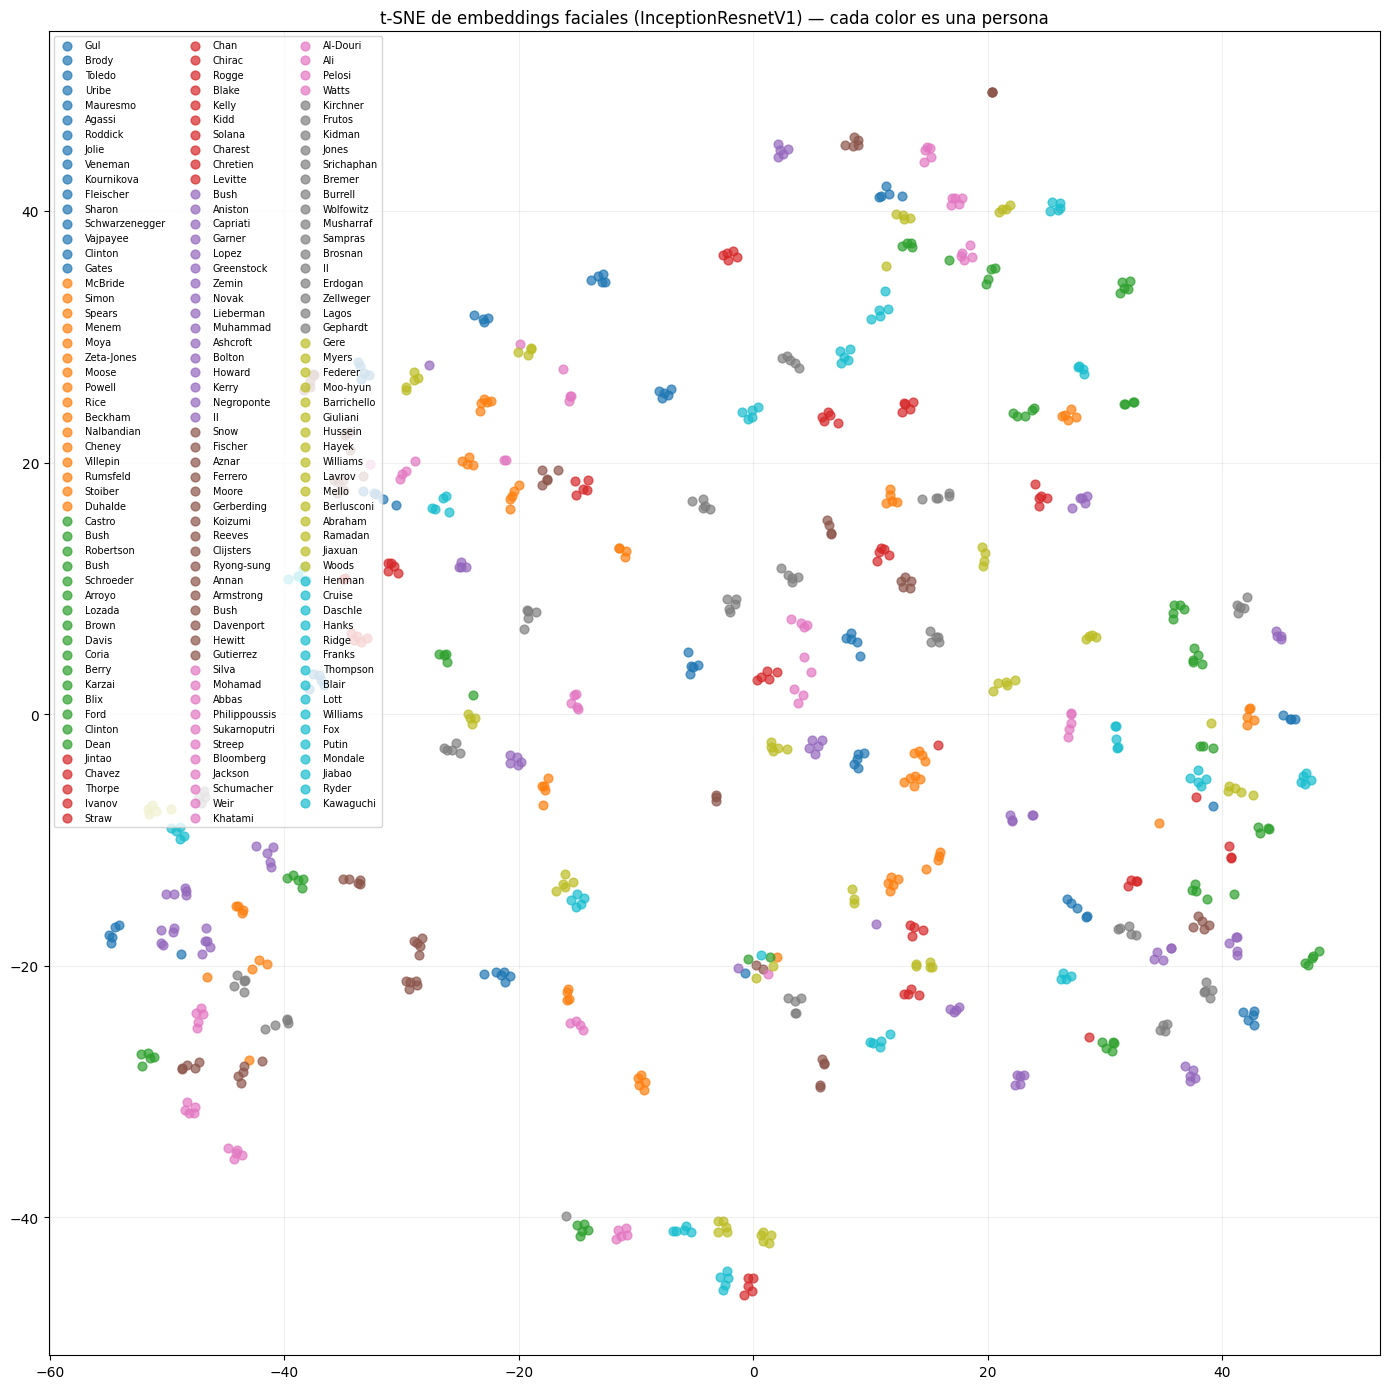

In [ ]:
# t-SNE sobre embeddings de TEST
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(test_emb_fn) - 1))
emb_2d = tsne.fit_transform(test_emb_fn)

fig, ax = plt.subplots(figsize=(14, 14))
colores = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES)))
for persona_id, nombre in enumerate(NOMBRES):
    mask = test_lbl_fn == persona_id
    if mask.any():
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])
ax.legend(fontsize=7, loc='best', ncol=3)
ax.set_title('t-SNE de embeddings faciales (InceptionResnetV1) — cada color es una persona')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Modelo 2 — ViT (Vision Transformer, pretrained en ImageNet)

Pipeline: imagen → **MTCNN** (detección y alineación de cara) → **ViT-Base/16** → embedding 768-d L2-normalizado.  
La identificación se hace por nearest-neighbor (similitud coseno = producto punto, ya que los embeddings están L2-normalizados).  
A diferencia del Modelo 1, ViT no fue preentrenado en datos de caras, por lo que aprende a reconocerlas de forma más genérica.

In [ ]:
modelo_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
modelo_vit = modelo_vit.eval().to(device)

print(f'ViT-Base/16 cargado | Embedding: {modelo_vit.num_features} dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_vit.parameters()) / 1e6:.1f}M')

def mtcnn_to_vit(t):
    """Convierte tensor MTCNN [-1,1] → normalización ImageNet."""
    t = (t * 0.5 + 0.5).clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=t.device).view(3,1,1)
    return (t - mean) / std

# Pre-normalizar el cache 224px a ImageNet — se reutiliza para ViT y ResNet-50
train_faces_224_in = torch.stack([mtcnn_to_vit(t) for t in train_faces_224])
test_faces_224_in  = torch.stack([mtcnn_to_vit(t) for t in test_faces_224])

finetune = True

ViT-Base/16 cargado | Embedding: 768 dimensiones
Parámetros: 85.8M


In [ ]:
if finetune:
    print("Finetuning ViT")

    X_train_vit = train_faces_224_in
    y_train_vit = torch.tensor(train_lbl_224, dtype=torch.long)

    dataset_vit = TensorDataset(X_train_vit, y_train_vit)
    val_size    = int(0.15 * len(dataset_vit))
    train_size  = len(dataset_vit) - val_size
    train_ds, val_ds = random_split(dataset_vit, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    # ── Congelar todo primero ──────────────────────────────────────────────
    for p in modelo_vit.parameters():
        p.requires_grad = False

    # ── Reemplazar cabeza ──────────────────────────────────────────────────
    modelo_vit.head = nn.Linear(modelo_vit.num_features, len(NOMBRES))

    # ── Descongelar últimos 3 bloques + norm + cabeza ──────────────────────
    NUM_BLOQUES = 3
    for bloque in modelo_vit.blocks[-NUM_BLOQUES:]:
        for p in bloque.parameters():
            p.requires_grad = True
    for p in modelo_vit.norm.parameters():
        p.requires_grad = True
    # la cabeza ya tiene requires_grad=True por ser nueva

    modelo_vit = modelo_vit.to(device)

    # ── Optimizer con LR diferencial ──────────────────────────────────────
    optimizer = torch.optim.AdamW([
        {"params": modelo_vit.blocks[-NUM_BLOQUES:].parameters(), "lr": 5e-5},
        {"params": modelo_vit.norm.parameters(),                  "lr": 5e-5},
        {"params": modelo_vit.head.parameters(),                  "lr": 3e-4},
    ], weight_decay=0.05)

    NUM_EPOCHS = 30
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc = 0
    patience     = 7
    no_improve   = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        modelo_vit.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                loss = criterion(modelo_vit(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * x.size(0)

        scheduler.step()

        modelo_vit.eval()
        correct = total = 0
        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (modelo_vit(x).argmax(1) == y).sum().item()
                total   += y.numel()

        val_acc = correct / total
        print(f"Epoch {epoch}/{NUM_EPOCHS}  "
              f"train_loss={running/train_size:.4f}  "
              f"val_acc={val_acc:.4f}  "
              f"lr_head={scheduler.get_last_lr()[0]:.2e}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(modelo_vit.state_dict(), "models/vit_ft_best.pth")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping en epoch {epoch} — mejor val_acc={best_val_acc:.4f}")
                break

    os.makedirs("models", exist_ok=True)
    print("Fine-tuning ViT done.")

Finetuning ViT
Epoch 1/30  train_loss=4.9513  val_acc=0.1048  lr_head=4.99e-05
Epoch 2/30  train_loss=2.7932  val_acc=0.4148  lr_head=4.95e-05
Epoch 3/30  train_loss=1.3435  val_acc=0.5939  lr_head=4.88e-05
Epoch 4/30  train_loss=1.0358  val_acc=0.6201  lr_head=4.78e-05
Epoch 5/30  train_loss=0.9555  val_acc=0.6332  lr_head=4.67e-05
Epoch 6/30  train_loss=0.9232  val_acc=0.6550  lr_head=4.52e-05
Epoch 7/30  train_loss=0.9059  val_acc=0.6507  lr_head=4.36e-05
Epoch 8/30  train_loss=0.8949  val_acc=0.6463  lr_head=4.17e-05
Epoch 9/30  train_loss=0.8873  val_acc=0.6550  lr_head=3.97e-05
Epoch 10/30  train_loss=0.8813  val_acc=0.6507  lr_head=3.75e-05
Epoch 11/30  train_loss=0.8765  val_acc=0.6463  lr_head=3.52e-05
Epoch 12/30  train_loss=0.8726  val_acc=0.6507  lr_head=3.27e-05
Epoch 13/30  train_loss=0.8693  val_acc=0.6550  lr_head=3.02e-05
Early stopping en epoch 13 — mejor val_acc=0.6550
Fine-tuning ViT done.


In [ ]:
def extraer_embeddings_vit(faces, labels, desc=''):
    """Recibe tensores ya normalizados a ImageNet (del cache)."""
    embs = []
    print(f'Extrayendo embeddings ViT {desc}...')
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            feat = modelo_vit(batch.to(device))
            embs.append(F.normalize(feat, p=2, dim=1).cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_vit, train_lbl_vit = extraer_embeddings_vit(train_faces_224_in, train_lbl_224, 'TRAIN')
test_emb_vit,  test_lbl_vit  = extraer_embeddings_vit(test_faces_224_in,  test_lbl_224,  'TEST')

Extrayendo embeddings ViT TRAIN...
  → 1533 embeddings | dim=158
Extrayendo embeddings ViT TEST...
  → 763 embeddings | dim=158


### Evaluación del modelo

In [ ]:
sims_vit = test_emb_vit @ train_emb_vit.T
pred_vit = train_lbl_vit[sims_vit.argmax(axis=1)]
acc_vit  = (pred_vit == test_lbl_vit).mean()

prec_vit, rec_vit, f1_vit, _ = precision_recall_fscore_support(
    test_lbl_vit, pred_vit, average='macro', zero_division=0
)

print(f'ViT-Base/16 — Rank-1')
print(f'  Accuracy:  {acc_vit:.3f}  ({(pred_vit == test_lbl_vit).sum()}/{len(test_lbl_vit)})')
print(f'  Precision: {prec_vit:.3f}')
print(f'  Recall:    {rec_vit:.3f}')
print(f'  F1:        {f1_vit:.3f}')

ViT-Base/16 — Rank-1
  Accuracy:  0.683  (521/763)
  Precision: 0.694
  Recall:    0.681
  F1:        0.666


In [ ]:
analizar_errores(test_lbl_vit, pred_vit, NOMBRES, 'ViT')


ViT — Clases con más falsos negativos (peor recall):
  Alejandro Toledo               5/5 errores (100%)
  Andy Roddick                   5/5 errores (100%)
  George HW Bush                 5/5 errores (100%)
  Lance Armstrong                5/5 errores (100%)
  Norah Jones                    5/5 errores (100%)
  Gerhard Schroeder              4/5 errores (80%)
  Gray Davis                     4/5 errores (80%)
  Mahathir Mohamad               4/4 errores (100%)
  Recep Tayyip Erdogan           4/5 errores (80%)
  Richard Gere                   4/5 errores (80%)

ViT — Confusiones más frecuentes:
  Andy Roddick              → Mike Weir                 (3x)
  Venus Williams            → Serena Williams           (3x)
  Gerhard Schroeder         → George Robertson          (2x)
  Hillary Clinton           → Nancy Pelosi              (2x)
  Howard Dean               → Paul Wolfowitz            (2x)
  Jennifer Lopez            → Catherine Zeta-Jones      (2x)
  Joe Lieberman             →

### Visualización de embeddings

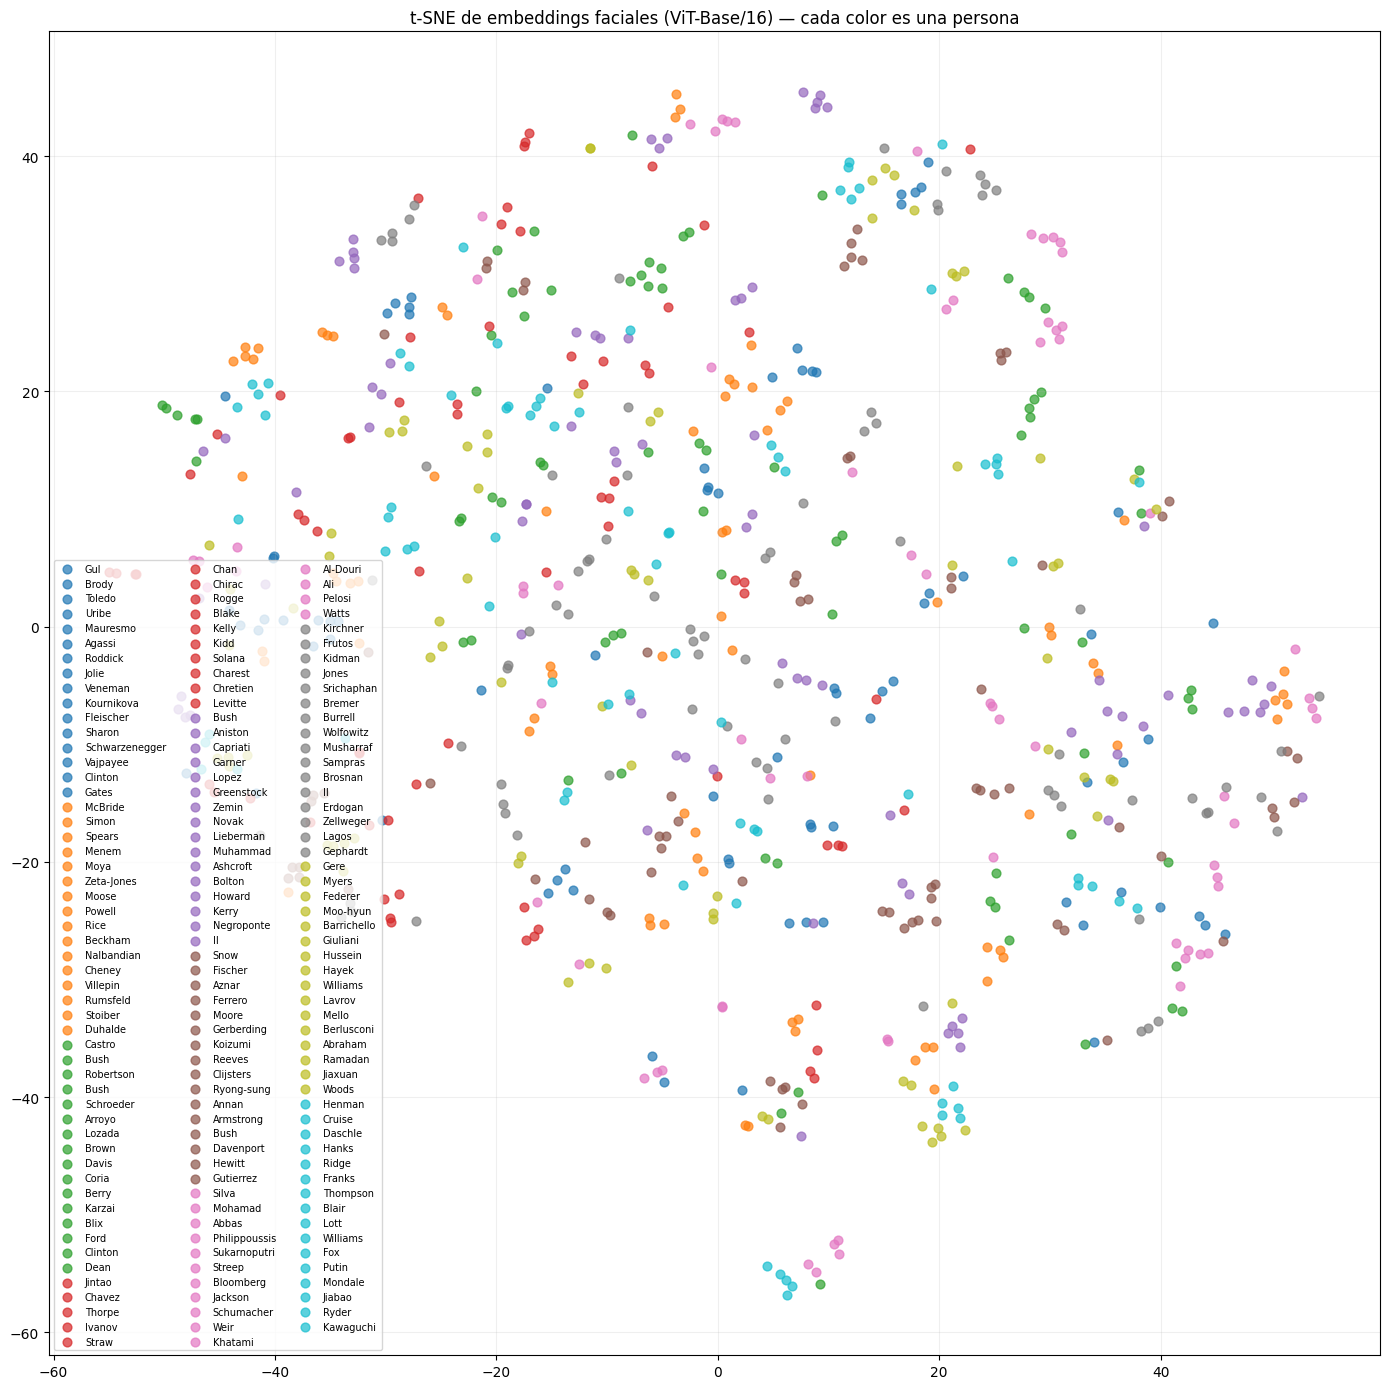

In [ ]:
# t-SNE sobre embeddings de TEST — ViT
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(test_emb_vit) - 1))
emb_2d_vit = tsne.fit_transform(test_emb_vit)

fig, ax = plt.subplots(figsize=(14, 14))
colores = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES)))
for persona_id, nombre in enumerate(NOMBRES):
    mask = test_lbl_vit == persona_id
    if mask.any():
        ax.scatter(emb_2d_vit[mask, 0], emb_2d_vit[mask, 1],
                   label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])
ax.legend(fontsize=7, loc='best', ncol=3)
ax.set_title('t-SNE de embeddings faciales (ViT-Base/16) — cada color es una persona')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Modelo 3 — ResNet-50 (pretrained en ImageNet)

Pipeline: imagen → **MTCNN** (detección y alineación de cara, 224×224) → **ResNet-50** → embedding 2048-d L2-normalizado.  
Mismo esquema que ViT: preentrenado en ImageNet (no en caras), fine-tuning de la cabeza de clasificación, identificación por nearest-neighbor.  
Permite comparar arquitectura CNN clásica profunda vs. Transformer (ViT) con el mismo protocolo.

In [ ]:
modelo_resnet = timm.create_model('resnet50', pretrained=True, num_classes=0)
modelo_resnet = modelo_resnet.eval().to(device)

print(f'ResNet-50 cargado | Embedding: {modelo_resnet.num_features} dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_resnet.parameters()) / 1e6:.1f}M')

# Reutiliza train_faces_224_in / test_faces_224_in definidos en la celda de ViT
# (mismo cache MTCNN 224px, misma normalización ImageNet)

finetune = True

ResNet-50 cargado | Embedding: 2048 dimensiones
Parámetros: 23.5M


In [ ]:
if finetune:
    print("Finetuning ResNet-50")

    X_train_rn = train_faces_224_in
    y_train_rn = torch.tensor(train_lbl_224, dtype=torch.long)

    dataset_rn = TensorDataset(X_train_rn, y_train_rn)
    val_size   = int(0.15 * len(dataset_rn))
    train_size = len(dataset_rn) - val_size
    train_ds, val_ds = random_split(dataset_rn, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    # ── Congelar todo ──────────────────────────────────────────────────────
    for p in modelo_resnet.parameters():
        p.requires_grad = False

    # ── Reemplazar cabeza ──────────────────────────────────────────────────
    # ResNet estándar de torchvision usa .fc, pero si viene de timm
    # puede ser .num_features o necesitar in_features directamente
    in_features = modelo_resnet.num_features          # ← Correcto para timm
    modelo_resnet.fc = nn.Linear(in_features, len(NOMBRES))

    # ── Descongelar layer4 (último bloque residual) + fc ──────────────────
    for p in modelo_resnet.layer4.parameters():
        p.requires_grad = True
    # fc ya es entrenable por ser nueva

    modelo_resnet = modelo_resnet.to(device)

    # ── Optimizer con LR diferencial ──────────────────────────────────────
    optimizer = torch.optim.AdamW([
        {"params": modelo_resnet.layer4.parameters(), "lr": 5e-5},
        {"params": modelo_resnet.fc.parameters(),     "lr": 3e-4},
    ], weight_decay=1e-4)   # ← ResNet prefiere weight_decay menor que ViT

    NUM_EPOCHS = 30
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc = 0
    patience     = 7
    no_improve   = 0

    os.makedirs("models", exist_ok=True)

    for epoch in range(1, NUM_EPOCHS + 1):
        modelo_resnet.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                loss = criterion(modelo_resnet(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * x.size(0)

        scheduler.step()

        modelo_resnet.eval()
        correct = total = 0
        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (modelo_resnet(x).argmax(1) == y).sum().item()
                total   += y.numel()

        val_acc = correct / total
        print(f"Epoch {epoch}/{NUM_EPOCHS}  "
              f"train_loss={running/train_size:.4f}  "
              f"val_acc={val_acc:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(modelo_resnet.state_dict(), "models/resnet50_ft_best.pth")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping en epoch {epoch} — mejor val_acc={best_val_acc:.4f}")
                break

    print("Fine-tuning ResNet-50 done.")

Finetuning ResNet-50
Epoch 1/30  train_loss=5.0894  val_acc=0.0044  lr=4.99e-05
Epoch 2/30  train_loss=4.9998  val_acc=0.0000  lr=4.95e-05
Epoch 3/30  train_loss=4.9390  val_acc=0.0044  lr=4.88e-05
Epoch 4/30  train_loss=4.8750  val_acc=0.0044  lr=4.78e-05
Epoch 5/30  train_loss=4.7958  val_acc=0.0087  lr=4.67e-05
Epoch 6/30  train_loss=4.7075  val_acc=0.0087  lr=4.52e-05
Epoch 7/30  train_loss=4.6052  val_acc=0.0218  lr=4.36e-05
Epoch 8/30  train_loss=4.4851  val_acc=0.0393  lr=4.17e-05
Epoch 9/30  train_loss=4.3630  val_acc=0.0437  lr=3.97e-05
Epoch 10/30  train_loss=4.2193  val_acc=0.0480  lr=3.75e-05
Epoch 11/30  train_loss=4.0775  val_acc=0.0480  lr=3.52e-05
Epoch 12/30  train_loss=3.9305  val_acc=0.0699  lr=3.27e-05
Epoch 13/30  train_loss=3.7837  val_acc=0.0655  lr=3.02e-05
Epoch 14/30  train_loss=3.6575  val_acc=0.0655  lr=2.76e-05
Epoch 15/30  train_loss=3.5487  val_acc=0.0786  lr=2.50e-05
Epoch 16/30  train_loss=3.4344  val_acc=0.0786  lr=2.24e-05
Epoch 17/30  train_loss=3.33

In [ ]:
def extraer_embeddings_resnet(faces, labels, desc=''):
    embs = []
    print(f'Extrayendo embeddings ResNet-50 {desc}...')
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            feat = modelo_resnet(batch.to(device))
            embs.append(F.normalize(feat, p=2, dim=1).cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_rn, train_lbl_rn = extraer_embeddings_resnet(train_faces_224_in, train_lbl_224, 'TRAIN')
test_emb_rn,  test_lbl_rn  = extraer_embeddings_resnet(test_faces_224_in,  test_lbl_224,  'TEST')

Extrayendo embeddings ResNet-50 TRAIN...
  → 1533 embeddings | dim=158
Extrayendo embeddings ResNet-50 TEST...
  → 763 embeddings | dim=158


### Evaluación del modelo

In [ ]:
sims_rn = test_emb_rn @ train_emb_rn.T
pred_rn = train_lbl_rn[sims_rn.argmax(axis=1)]
acc_rn  = (pred_rn == test_lbl_rn).mean()

prec_rn, rec_rn, f1_rn, _ = precision_recall_fscore_support(
    test_lbl_rn, pred_rn, average='macro', zero_division=0
)

print(f'ResNet-50 — Rank-1')
print(f'  Accuracy:  {acc_rn:.3f}  ({(pred_rn == test_lbl_rn).sum()}/{len(test_lbl_rn)})')
print(f'  Precision: {prec_rn:.3f}')
print(f'  Recall:    {rec_rn:.3f}')
print(f'  F1:        {f1_rn:.3f}')

ResNet-50 — Rank-1
  Accuracy:  0.100  (76/763)
  Precision: 0.115
  Recall:    0.101
  F1:        0.100


In [ ]:
analizar_errores(test_lbl_rn,  pred_rn,  NOMBRES, 'ResNet-50')


ResNet-50 — Clases con más falsos negativos (peor recall):
  Abdullah Gul                   5/5 errores (100%)
  Adrien Brody                   5/5 errores (100%)
  Alejandro Toledo               5/5 errores (100%)
  Amelie Mauresmo                5/5 errores (100%)
  Andre Agassi                   5/5 errores (100%)
  Andy Roddick                   5/5 errores (100%)
  Angelina Jolie                 5/5 errores (100%)
  Ann Veneman                    5/5 errores (100%)
  Ariel Sharon                   5/5 errores (100%)
  Arnold Schwarzenegger          5/5 errores (100%)

ResNet-50 — Confusiones más frecuentes:
  Juan Carlos Ferrero       → Serena Williams           (3x)
  Catherine Zeta-Jones      → Angelina Jolie            (2x)
  Condoleezza Rice          → Halle Berry               (2x)
  Guillermo Coria           → Lance Armstrong           (2x)
  Jack Straw                → Donald Rumsfeld           (2x)
  James Kelly               → Alejandro Toledo          (2x)
  Jennifer An

### Visualización de embeddings

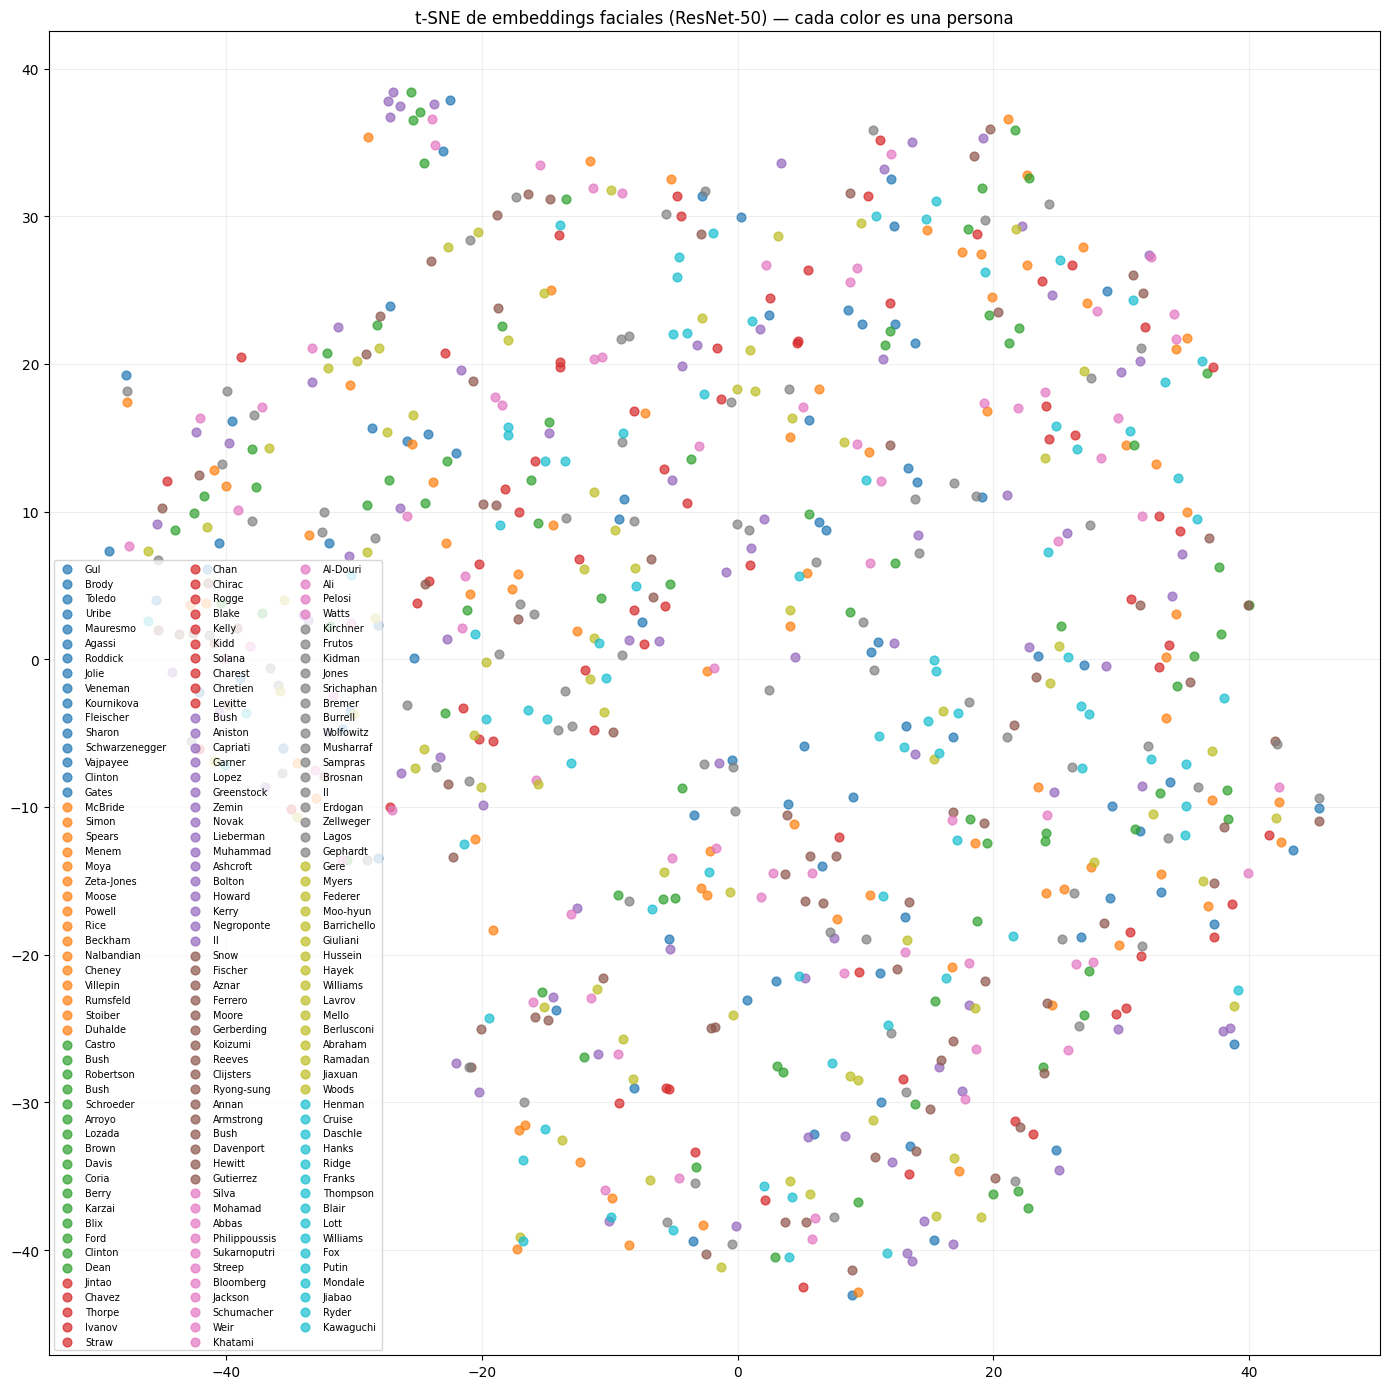

In [ ]:
# t-SNE sobre embeddings de TEST — ResNet-50
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(test_emb_rn) - 1))
emb_2d_rn = tsne.fit_transform(test_emb_rn)

fig, ax = plt.subplots(figsize=(14, 14))
colores = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES)))
for persona_id, nombre in enumerate(NOMBRES):
    mask = test_lbl_rn == persona_id
    if mask.any():
        ax.scatter(emb_2d_rn[mask, 0], emb_2d_rn[mask, 1],
                   label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])
ax.legend(fontsize=7, loc='best', ncol=3)
ax.set_title('t-SNE de embeddings faciales (ResNet-50) — cada color es una persona')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Modelo 4 — LightFaceCNN (sin preentrenamiento)

Pipeline: imagen → **MTCNN** (detección y alineación de cara, 96×96) → **LightFaceCNN** → embedding 256-d L2-normalizado.  
Usa **depthwise separable convolutions** (como MobileNet) para reducir parámetros, y **residual connections** para mejorar el gradiente.  
Aunque parte desde cero (sin preentrenamiento), compite razonablemente en LFW gracias al pipeline MTCNN y al entrenamiento con scheduler.

In [ ]:
class DepthwiseSeparable(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6()

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = DepthwiseSeparable(ch, ch)
        self.conv2 = DepthwiseSeparable(ch, ch)
        self.bn    = nn.BatchNorm2d(ch)          # ← BN después del bloque

    def forward(self, x):
        return self.bn(x + self.conv2(self.conv1(x)))   # ← BN sobre la suma


class LightFaceCNN(nn.Module):
    def __init__(self, emb_dim=256, num_classes=None):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(),
        )
        self.stage1 = nn.Sequential(DepthwiseSeparable(32,  64,  stride=2), ResBlock(64))
        self.stage2 = nn.Sequential(DepthwiseSeparable(64,  128, stride=2), ResBlock(128))
        self.stage3 = nn.Sequential(DepthwiseSeparable(128, 256, stride=2), ResBlock(256))
        self.pool   = nn.AdaptiveAvgPool2d(1)

        self.embedder = nn.Sequential(
            nn.Linear(256, emb_dim, bias=False),
            nn.BatchNorm1d(emb_dim),             # ← BN antes del Dropout
            nn.Dropout(0.2),                     # ← Dropout reducido y después de BN
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)              # (B, 256) — más claro que squeeze
        x = self.embedder(x)
        return F.normalize(x, p=2, dim=1)

modelo_cnn = LightFaceCNN(emb_dim=256).to(device)
print(f'LightFaceCNN (mejorado) | Embedding: 256 dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_cnn.parameters()) / 1e6:.3f}M')

LightFaceCNN (mejorado) | Embedding: 256 dimensiones
Parámetros: 0.296M


In [ ]:
X_train_cnn = train_faces_96                               # cache directo
y_train_cnn = torch.tensor(train_lbl_96, dtype=torch.long)

dataset_cnn = TensorDataset(X_train_cnn, y_train_cnn)
val_size    = int(0.15 * len(dataset_cnn))
train_size  = len(dataset_cnn) - val_size
train_ds, val_ds = random_split(dataset_cnn, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=0)

# Head de clasificación (solo para entrenar embeddings, no se usa en inferencia)
head_cnn  = nn.Linear(256, len(NOMBRES)).to(device)
optimizer = torch.optim.AdamW(
    list(modelo_cnn.parameters()) + list(head_cnn.parameters()),
    lr=1e-3, weight_decay=1e-4)

# Cosine annealing: baja el lr suavemente, mejora convergencia sin sobreajustar
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing mejora generalización
scaler    = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

EPOCHS = 15   # más epochs pero scheduler evita sobreajuste
for epoch in range(1, EPOCHS + 1):
    modelo_cnn.train(); head_cnn.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            loss = criterion(head_cnn(modelo_cnn(x)), y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item() * x.size(0)
    scheduler.step()

    modelo_cnn.eval(); head_cnn.eval()
    correct = total = 0
    with torch.inference_mode():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            correct += (head_cnn(modelo_cnn(x)).argmax(1) == y).sum().item()
            total   += y.numel()
    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={running/train_size:.4f}  val_acc={correct/total:.4f}  lr={lr_now:.2e}")

os.makedirs("models", exist_ok=True)
torch.save(modelo_cnn, "models/lightcnn.pth")
print("Entrenamiento LightFaceCNN done.")

Epoch 01/15  train_loss=5.0533  val_acc=0.0044  lr=9.89e-04
Epoch 02/15  train_loss=4.9846  val_acc=0.0000  lr=9.57e-04
Epoch 03/15  train_loss=4.9179  val_acc=0.0306  lr=9.05e-04
Epoch 04/15  train_loss=4.8383  val_acc=0.0480  lr=8.36e-04
Epoch 05/15  train_loss=4.7525  val_acc=0.0524  lr=7.52e-04
Epoch 06/15  train_loss=4.6646  val_acc=0.0349  lr=6.58e-04
Epoch 07/15  train_loss=4.5868  val_acc=0.0611  lr=5.57e-04
Epoch 08/15  train_loss=4.5170  val_acc=0.0524  lr=4.53e-04
Epoch 09/15  train_loss=4.4542  val_acc=0.0480  lr=3.52e-04
Epoch 10/15  train_loss=4.4057  val_acc=0.0568  lr=2.58e-04
Epoch 11/15  train_loss=4.3701  val_acc=0.0568  lr=1.74e-04
Epoch 12/15  train_loss=4.3435  val_acc=0.0480  lr=1.05e-04
Epoch 13/15  train_loss=4.3231  val_acc=0.0611  lr=5.28e-05
Epoch 14/15  train_loss=4.3096  val_acc=0.0568  lr=2.08e-05
Epoch 15/15  train_loss=4.3090  val_acc=0.0568  lr=1.00e-05
Entrenamiento LightFaceCNN done.


In [ ]:
def extraer_embeddings_cnn(faces, labels, desc=''):
    embs = []
    print(f'Extrayendo embeddings CNN {desc}...')
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            feat = modelo_cnn(batch.to(device))
            embs.append(feat.cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_cnn, train_lbl_cnn = extraer_embeddings_cnn(train_faces_96, train_lbl_96, 'TRAIN')
test_emb_cnn,  test_lbl_cnn  = extraer_embeddings_cnn(test_faces_96,  test_lbl_96,  'TEST')

Extrayendo embeddings CNN TRAIN...
  → 1533 embeddings | dim=256
Extrayendo embeddings CNN TEST...
  → 763 embeddings | dim=256


### Evaluación del modelo

In [ ]:
sims_cnn = test_emb_cnn @ train_emb_cnn.T
pred_cnn = train_lbl_cnn[sims_cnn.argmax(axis=1)]
acc_cnn  = (pred_cnn == test_lbl_cnn).mean()

prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(
    test_lbl_cnn, pred_cnn, average='macro', zero_division=0
)

print(f'LightFaceCNN — Rank-1')
print(f'  Accuracy:  {acc_cnn:.3f}  ({(pred_cnn == test_lbl_cnn).sum()}/{len(test_lbl_cnn)})')
print(f'  Precision: {prec_cnn:.3f}')
print(f'  Recall:    {rec_cnn:.3f}')
print(f'  F1:        {f1_cnn:.3f}')

LightFaceCNN — Rank-1
  Accuracy:  0.075  (57/763)
  Precision: 0.077
  Recall:    0.074
  F1:        0.069


In [ ]:
analizar_errores(test_lbl_cnn, pred_cnn, NOMBRES, 'LightFaceCNN')


LightFaceCNN — Clases con más falsos negativos (peor recall):
  Alejandro Toledo               5/5 errores (100%)
  Amelie Mauresmo                5/5 errores (100%)
  Andre Agassi                   5/5 errores (100%)
  Angelina Jolie                 5/5 errores (100%)
  Ann Veneman                    5/5 errores (100%)
  Ariel Sharon                   5/5 errores (100%)
  Arnold Schwarzenegger          5/5 errores (100%)
  Bill Gates                     5/5 errores (100%)
  Bill McBride                   5/5 errores (100%)
  Bill Simon                     5/5 errores (100%)

LightFaceCNN — Confusiones más frecuentes:
  Angelina Jolie            → Yoriko Kawaguchi          (2x)
  Ann Veneman               → Yoriko Kawaguchi          (2x)
  Bill Clinton              → Gonzalo Sanchez de Lozada (2x)
  Carlos Moya               → Anna Kournikova           (2x)
  Charles Moose             → Kofi Annan                (2x)
  Dominique de Villepin     → Sergio Vieira De Mello    (2x)
  Donal

### Visualización de embeddings

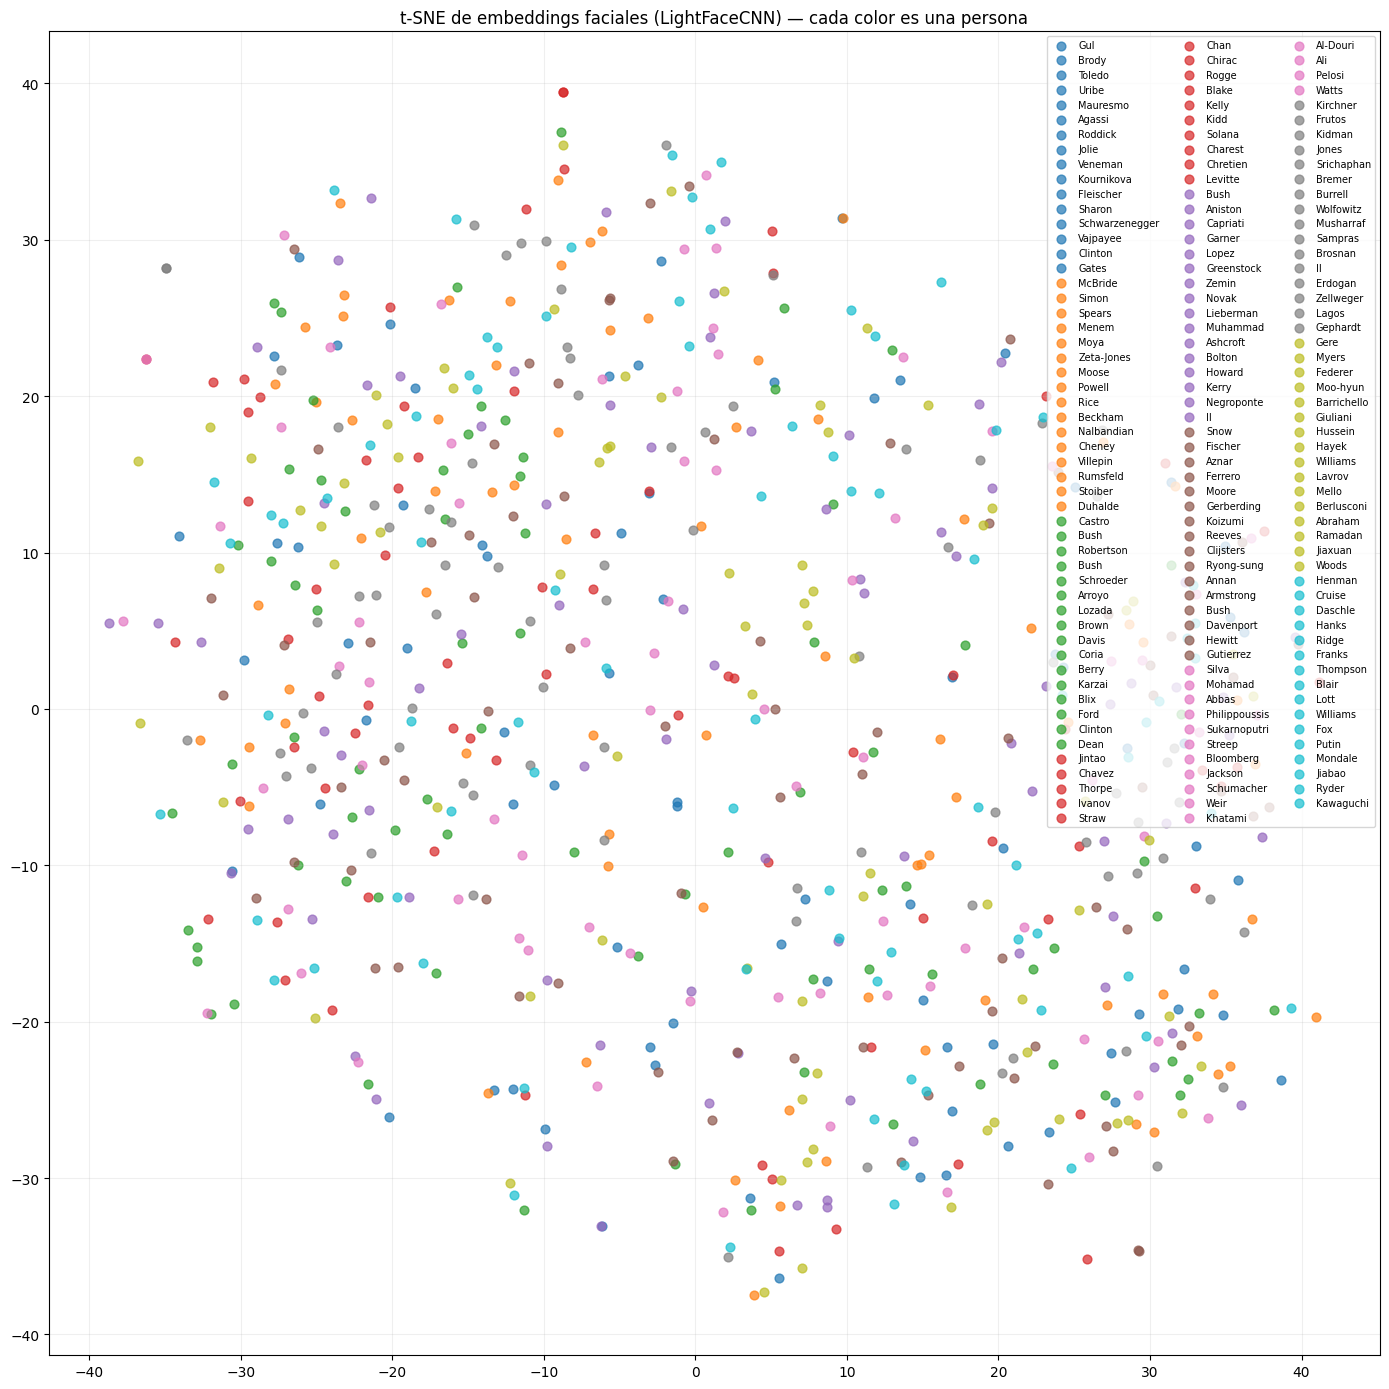

In [ ]:
# t-SNE sobre embeddings de TEST — LightFaceCNN
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(test_emb_cnn) - 1))
emb_2d_cnn = tsne.fit_transform(test_emb_cnn)

fig, ax = plt.subplots(figsize=(14, 14))
colores = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES)))
for persona_id, nombre in enumerate(NOMBRES):
    mask = test_lbl_cnn == persona_id
    if mask.any():
        ax.scatter(emb_2d_cnn[mask, 0], emb_2d_cnn[mask, 1],
                   label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])
ax.legend(fontsize=7, loc='best', ncol=3)
ax.set_title('t-SNE de embeddings faciales (LightFaceCNN) — cada color es una persona')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Comparación de modelos

  Modelo                            Acc   Prec    Rec     F1
  InceptionResnetV1 (FaceNet)     0.961  0.966  0.958  0.958
  ViT-Base/16                     0.683  0.694  0.681  0.666
  ResNet-50                       0.100  0.115  0.101  0.100
  LightFaceCNN (desde cero)       0.075  0.077  0.074  0.069
  Dataset: 158 clases, 1580 train / 790 test


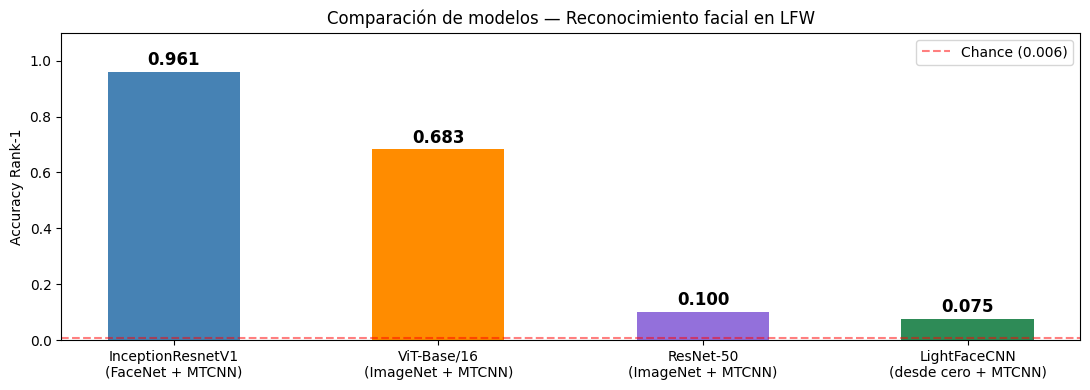

In [ ]:
print('=' * 70)
print(f'  {"Modelo":<30} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6}')
print('=' * 70)
print(f'  {"InceptionResnetV1 (FaceNet)":<30} {acc_fn:>6.3f} {prec_fn:>6.3f} {rec_fn:>6.3f} {f1_fn:>6.3f}')
print(f'  {"ViT-Base/16":<30} {acc_vit:>6.3f} {prec_vit:>6.3f} {rec_vit:>6.3f} {f1_vit:>6.3f}')
print(f'  {"ResNet-50":<30} {acc_rn:>6.3f} {prec_rn:>6.3f} {rec_rn:>6.3f} {f1_rn:>6.3f}')
print(f'  {"LightFaceCNN (desde cero)":<30} {acc_cnn:>6.3f} {prec_cnn:>6.3f} {rec_cnn:>6.3f} {f1_cnn:>6.3f}')
print('=' * 70)
print(f'  Dataset: {len(NOMBRES)} clases, {len(X_train_raw)} train / {len(X_test_raw)} test')

fig, ax = plt.subplots(figsize=(11, 4))
modelos = [
    'InceptionResnetV1\n(FaceNet + MTCNN)',
    'ViT-Base/16\n(ImageNet + MTCNN)',
    'ResNet-50\n(ImageNet + MTCNN)',
    'LightFaceCNN\n(desde cero + MTCNN)',
]
accs    = [acc_fn, acc_vit, acc_rn, acc_cnn]
colores = ['steelblue', 'darkorange', 'mediumpurple', 'seagreen']
bars = ax.bar(modelos, accs, color=colores, width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy Rank-1')
ax.set_title('Comparación de modelos — Reconocimiento facial en LFW')
ax.axhline(1/len(NOMBRES), color='red', linestyle='--', alpha=0.5,
           label=f'Chance ({1/len(NOMBRES):.3f})')
ax.legend()
plt.tight_layout()
plt.show()